# National Job Market Predictor (Model-Ready CSV)

This notebook uses the prebuilt `annual_wage_model_data_2010_2024.csv` file to train and evaluate the same occupation-level forecasting model from the original notebook. The raw BLS/OEWS file discovery, cleaning, schema standardization, and target-building steps are skipped because they have already been saved in the CSV.

**Model choice:** Random Forest regression is used as the main model. It predicts each occupation's next-year employment and annual mean wage from the current year's occupation, employment, annual wage, and SOC-code features.

## Report Summary

### Data Used

The notebook reads the model-ready `annual_wage_model_data_2010_2024.csv` file. That CSV already contains the cleaned annual-wage panel, one-year-ahead targets, SOC-code features, log transforms, employment share, and train/holdout split labels.

### Preprocessing Skipped

The original notebook's raw-file preprocessing is not repeated here. This version does not discover BLS/OEWS source files, standardize raw column names, remove hourly wage fields, filter occupation groups, or create lagged targets from scratch.

### Modeling

The model predicts next-year `TOT_EMP` and next-year annual mean wage `A_MEAN`. It uses a `RandomForestRegressor`, which averages many decision trees so the final prediction is less dependent on any single tree. The trees learn nonlinear relationships between prior-year employment, annual wage levels, wage percentiles, SOC-code groupings, occupation title/code, and year.

### Validation

The notebook uses the same time-aware split. It trains on transitions whose target year is 2022 or earlier, then tests on 2023 and 2024 target years. This avoids training directly on the outcomes being scored.

In [19]:
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "annual_wage_model_data_2010_2024.csv"

In [20]:
model_data = pd.read_csv(DATA_PATH)
model_data = model_data.rename(columns={"TARGET_YEAR": "NEXT_YEAR"})

numeric_columns = [
    "YEAR",
    "NEXT_YEAR",
    "TOT_EMP",
    "EMP_PRSE",
    "A_MEAN",
    "MEAN_PRSE",
    "A_PCT10",
    "A_PCT25",
    "A_MEDIAN",
    "A_PCT75",
    "A_PCT90",
    "LOG_TOT_EMP",
    "LOG_A_MEAN",
    "EMPLOYMENT_SHARE",
    "NEXT_TOT_EMP",
    "NEXT_A_MEAN",
    "TARGET_LOG_TOT_EMP",
    "TARGET_LOG_A_MEAN",
]
for column in numeric_columns:
    if column in model_data.columns:
        model_data[column] = pd.to_numeric(model_data[column], errors="coerce")

model_data["YEAR"] = model_data["YEAR"].astype(int)
model_data["NEXT_YEAR"] = model_data["NEXT_YEAR"].astype(int)

# Rebuild a panel-shaped table for the unchanged final forecast section.
# The model-ready CSV contains completed transitions, so the latest feature year
# is reconstructed from the latest target values saved in the CSV.
panel = model_data.copy()
latest_target_year = int(model_data["NEXT_YEAR"].max())
latest_target_features = model_data[model_data["NEXT_YEAR"].eq(latest_target_year)].copy()
latest_target_features["YEAR"] = latest_target_features["NEXT_YEAR"]
latest_target_features["TOT_EMP"] = latest_target_features["NEXT_TOT_EMP"]
latest_target_features["A_MEAN"] = latest_target_features["NEXT_A_MEAN"]
latest_target_features["LOG_TOT_EMP"] = latest_target_features["TARGET_LOG_TOT_EMP"]
latest_target_features["LOG_A_MEAN"] = latest_target_features["TARGET_LOG_A_MEAN"]
latest_target_features["EMPLOYMENT_SHARE"] = (
    latest_target_features["TOT_EMP"] / latest_target_features["TOT_EMP"].sum()
)

for unavailable_column in ["EMP_PRSE", "MEAN_PRSE", "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90"]:
    if unavailable_column in latest_target_features.columns:
        latest_target_features[unavailable_column] = np.nan

panel = (
    pd.concat([panel, latest_target_features], ignore_index=True)
    .sort_values(["OCC_CODE", "YEAR"])
    .drop_duplicates(["OCC_CODE", "YEAR"], keep="last")
    .reset_index(drop=True)
)

print(f"Loaded {model_data.shape[0]} model rows from {DATA_PATH.name}")
print("Training/holdout target years:", sorted(model_data["NEXT_YEAR"].unique()))
print("Panel feature years:", sorted(panel["YEAR"].unique()))
model_data.head()

Loaded 9584 model rows from annual_wage_model_data_2010_2024.csv
Training/holdout target years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Panel feature years: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,YEAR,NEXT_YEAR,OCC_CODE,OCC_TITLE,SOURCE_FILE,OCC_MAJOR,OCC_MINOR,TOT_EMP,EMP_PRSE,A_MEAN,MEAN_PRSE,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,LOG_TOT_EMP,LOG_A_MEAN,EMPLOYMENT_SHARE,NEXT_TOT_EMP,NEXT_A_MEAN,TARGET_LOG_TOT_EMP,TARGET_LOG_A_MEAN,DATA_SPLIT
0,2012,2013,11-1011,Chief Executives,converted_csv/oesm12nat/national_M2012_dl__nat...,11,11-10,255940.0,0.6,176840.0,0.3,76220.0,109940.0,168140.0,NaN,NaN,12.452702,12.083006,0.001964,248760,178400,12.424248,12.091789,train_through_2022
1,2013,2014,11-1011,Chief Executives,converted_csv/oesm13nat/national_M2013_dl__nat...,11,11-10,248760.0,0.6,178400.0,0.3,75030.0,110610.0,171610.0,NaN,NaN,12.424248,12.091789,0.001876,246240,180700,12.414066,12.104599,train_through_2022
2,2014,2015,11-1011,Chief Executives,converted_csv/oesm14nat/national_M2014_dl__nat...,11,11-10,246240.0,0.8,180700.0,0.4,72750.0,110760.0,173320.0,NaN,NaN,12.414066,12.104599,0.001822,238940,185850,12.383972,12.132701,train_through_2022
3,2015,2016,11-1011,Chief Executives,converted_csv/oesm15nat/national_M2015_dl__nat...,11,11-10,238940.0,0.7,185850.0,0.4,68600.0,111040.0,175110.0,NaN,NaN,12.383972,12.132701,0.001733,223260,194350,12.316097,12.177421,train_through_2022
4,2016,2017,11-1011,Chief Executives,converted_csv/oesm16nat/national_M2016_dl__nat...,11,11-10,223260.0,0.7,194350.0,0.4,69780.0,114100.0,181210.0,NaN,NaN,12.316097,12.177421,0.001590,210160,196050,12.255629,12.186130,train_through_2022


In [21]:
FEATURE_COLUMNS = [
    "YEAR",
    "OCC_CODE",
    "OCC_TITLE",
    "OCC_MAJOR",
    "OCC_MINOR",
    "TOT_EMP",
    "EMP_PRSE",
    "A_MEAN",
    "MEAN_PRSE",
    "A_PCT10",
    "A_PCT25",
    "A_MEDIAN",
    "A_PCT75",
    "A_PCT90",
    "LOG_TOT_EMP",
    "LOG_A_MEAN",
    "EMPLOYMENT_SHARE",
]
TARGET_COLUMNS = ["TARGET_LOG_TOT_EMP", "TARGET_LOG_A_MEAN"]
TRAIN_TARGET_END_YEAR = 2022
TEST_TARGET_YEARS = [2023, 2024]

available_features = [column for column in FEATURE_COLUMNS if column in model_data.columns]
categorical_features = ["OCC_CODE", "OCC_TITLE", "OCC_MAJOR", "OCC_MINOR"]
numeric_features = [column for column in available_features if column not in categorical_features]

train_data = model_data[model_data["NEXT_YEAR"].le(TRAIN_TARGET_END_YEAR)].copy()
test_data = model_data[model_data["NEXT_YEAR"].isin(TEST_TARGET_YEARS)].copy()

print(f"Training target years: {int(train_data['NEXT_YEAR'].min())}-{int(train_data['NEXT_YEAR'].max())}")
print("Testing target years:", sorted(test_data["NEXT_YEAR"].astype(int).unique()))
print("Train rows:", train_data.shape[0], "Test rows:", test_data.shape[0])

Training target years: 2013-2022
Testing target years: [np.int64(2023), np.int64(2024)]
Train rows: 7933 Test rows: 1651


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import pandas as pd # Explicitly importing pandas
import numpy as np # Explicitly importing numpy
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define regression_report and make_metrics here for scope
def regression_report(actual: pd.Series, predicted: pd.Series) -> dict[str, float]:
    actual = pd.Series(actual, dtype="float64")
    predicted = pd.Series(predicted, dtype="float64")
    wape = actual.sub(predicted).abs().sum() / actual.abs().sum()
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "WAPE": wape,
        "ACCURACY_PERCENT": (1 - wape) * 100,
        "R2": r2_score(actual, predicted),
    }

def make_metrics(data: pd.DataFrame, label: str) -> list[dict[str, float | str | int]]:
    return [
        {"split": label, "target": "TOT_EMP", **regression_report(data["ACTUAL_TOT_EMP"], data["PREDICTED_TOT_EMP"])},
        {"split": label, "target": "A_MEAN", **regression_report(data["ACTUAL_A_MEAN"], data["PREDICTED_A_MEAN"])},
    ]


N_ESTIMATORS_VALUES = [300, 500, 1000]
all_metrics_by_n_estimators = []

for n_estimators_val in N_ESTIMATORS_VALUES:
    print(f"\nTraining model with n_estimators={n_estimators_val}...")
    model = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "forest",
                RandomForestRegressor(
                    n_estimators=n_estimators_val,
                    min_samples_leaf=3,
                    random_state=42,
                    n_jobs=1,
                ),
            ),
        ]
    )

    model.fit(train_data[available_features], train_data[TARGET_COLUMNS])
    predicted_log = model.predict(test_data[available_features])
    current_predictions = pd.DataFrame(
        {
            "YEAR": test_data["YEAR"].to_numpy(),
            "TARGET_YEAR": test_data["NEXT_YEAR"].to_numpy().astype(int),
            "OCC_CODE": test_data["OCC_CODE"].to_numpy(),
            "OCC_TITLE": test_data["OCC_TITLE"].to_numpy(),
            "ACTUAL_TOT_EMP": test_data["NEXT_TOT_EMP"].to_numpy(),
            "PREDICTED_TOT_EMP": np.expm1(predicted_log[:, 0]),
            "ACTUAL_A_MEAN": test_data["NEXT_A_MEAN"].to_numpy(),
            "PREDICTED_A_MEAN": np.expm1(predicted_log[:, 1]),
        }
    )

    current_metrics_by_year = pd.DataFrame(
        row
        for target_year, year_predictions in current_predictions.groupby("TARGET_YEAR")
        for row in make_metrics(year_predictions, int(target_year))
    )
    current_metrics_by_year["n_estimators"] = n_estimators_val
    all_metrics_by_n_estimators.append(current_metrics_by_year)

# Concatenate all metrics into a single DataFrame for easier plotting
combined_metrics_by_year = pd.concat(all_metrics_by_n_estimators, ignore_index=True)

# Restore 'predictions' and 'metrics' to reflect the n_estimators=500 case for consistency with existing notebook cells
# First, re-run the 500 estimators model to ensure 'predictions' is correctly set.
print("\nRestoring 'predictions' and 'metrics' variables for n_estimators=500 (default)...")
model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "forest",
            RandomForestRegressor(
                n_estimators=500,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=1,
            ),
        ),
    ]
)
model.fit(train_data[available_features], train_data[TARGET_COLUMNS])
predicted_log = model.predict(test_data[available_features])
predictions = pd.DataFrame(
    {
        "YEAR": test_data["YEAR"].to_numpy(),
        "TARGET_YEAR": test_data["NEXT_YEAR"].to_numpy().astype(int),
        "OCC_CODE": test_data["OCC_CODE"].to_numpy(),
        "OCC_TITLE": test_data["OCC_TITLE"].to_numpy(),
        "ACTUAL_TOT_EMP": test_data["NEXT_TOT_EMP"].to_numpy(),
        "PREDICTED_TOT_EMP": np.expm1(predicted_log[:, 0]),
        "ACTUAL_A_MEAN": test_data["NEXT_A_MEAN"].to_numpy(),
        "PREDICTED_A_MEAN": np.expm1(predicted_log[:, 1]),
    }
)
metrics = pd.DataFrame(make_metrics(predictions, "2023-2024 holdout"))


Training model with n_estimators=300...

Training model with n_estimators=500...

Training model with n_estimators=1000...

Restoring 'predictions' and 'metrics' variables for n_estimators=500 (default)...


In [23]:
def regression_report(actual: pd.Series, predicted: pd.Series) -> dict[str, float]:
    actual = pd.Series(actual, dtype="float64")
    predicted = pd.Series(predicted, dtype="float64")
    wape = actual.sub(predicted).abs().sum() / actual.abs().sum()
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "WAPE": wape,
        "ACCURACY_PERCENT": (1 - wape) * 100,
        "R2": r2_score(actual, predicted),
    }


def make_metrics(data: pd.DataFrame, label: str) -> list[dict[str, float | str | int]]:
    return [
        {"split": label, "target": "TOT_EMP", **regression_report(data["ACTUAL_TOT_EMP"], data["PREDICTED_TOT_EMP"])},
        {"split": label, "target": "A_MEAN", **regression_report(data["ACTUAL_A_MEAN"], data["PREDICTED_A_MEAN"])},
    ]


metrics = pd.DataFrame(make_metrics(predictions, "2023-2024 holdout"))
metrics_by_year = pd.DataFrame(
    row
    for target_year, year_predictions in predictions.groupby("TARGET_YEAR")
    for row in make_metrics(year_predictions, int(target_year))
)

display(metrics)
metrics_by_year

,split,target,MAE,RMSE,WAPE,ACCURACY_PERCENT,R2
0,2023-2024 holdout,TOT_EMP,11438.657054,44847.885625,0.061757,93.824281,0.989725
1,2023-2024 holdout,A_MEAN,4625.957917,16704.205314,0.060250,93.975029,0.888921


,split,target,MAE,RMSE,WAPE,ACCURACY_PERCENT,R2
0,2023,TOT_EMP,10835.151654,41829.610540,0.058917,94.108268,0.990941
1,2023,A_MEAN,4542.963974,15737.115709,0.060229,93.977058,0.899255
2,2024,TOT_EMP,12041.431818,47672.136990,0.064554,93.544636,0.988543
3,2024,A_MEAN,4708.851384,17617.211949,0.060269,93.973072,0.878859


### Model Evaluation

The model is evaluated on held-out 2023 and 2024 target years, which were not used for training. The table above summarizes error with `MAE`, `RMSE`, `WAPE`, accuracy percent, and `R2`.

For a class presentation, the most useful visuals are actual-versus-predicted plots, residual distributions, and year-by-year metric comparisons. Together, they show whether predictions follow the true values, whether errors are centered near zero, and whether performance is stable across the holdout years.

The final plots below focus on the `TOT_EMP` loss requested here, calculated as:

$$
\text{loss} = \hat{y}_{TOT\_EMP} - y_{TOT\_EMP}
$$

Positive values mean the model over-predicted employment; negative values mean it under-predicted employment.

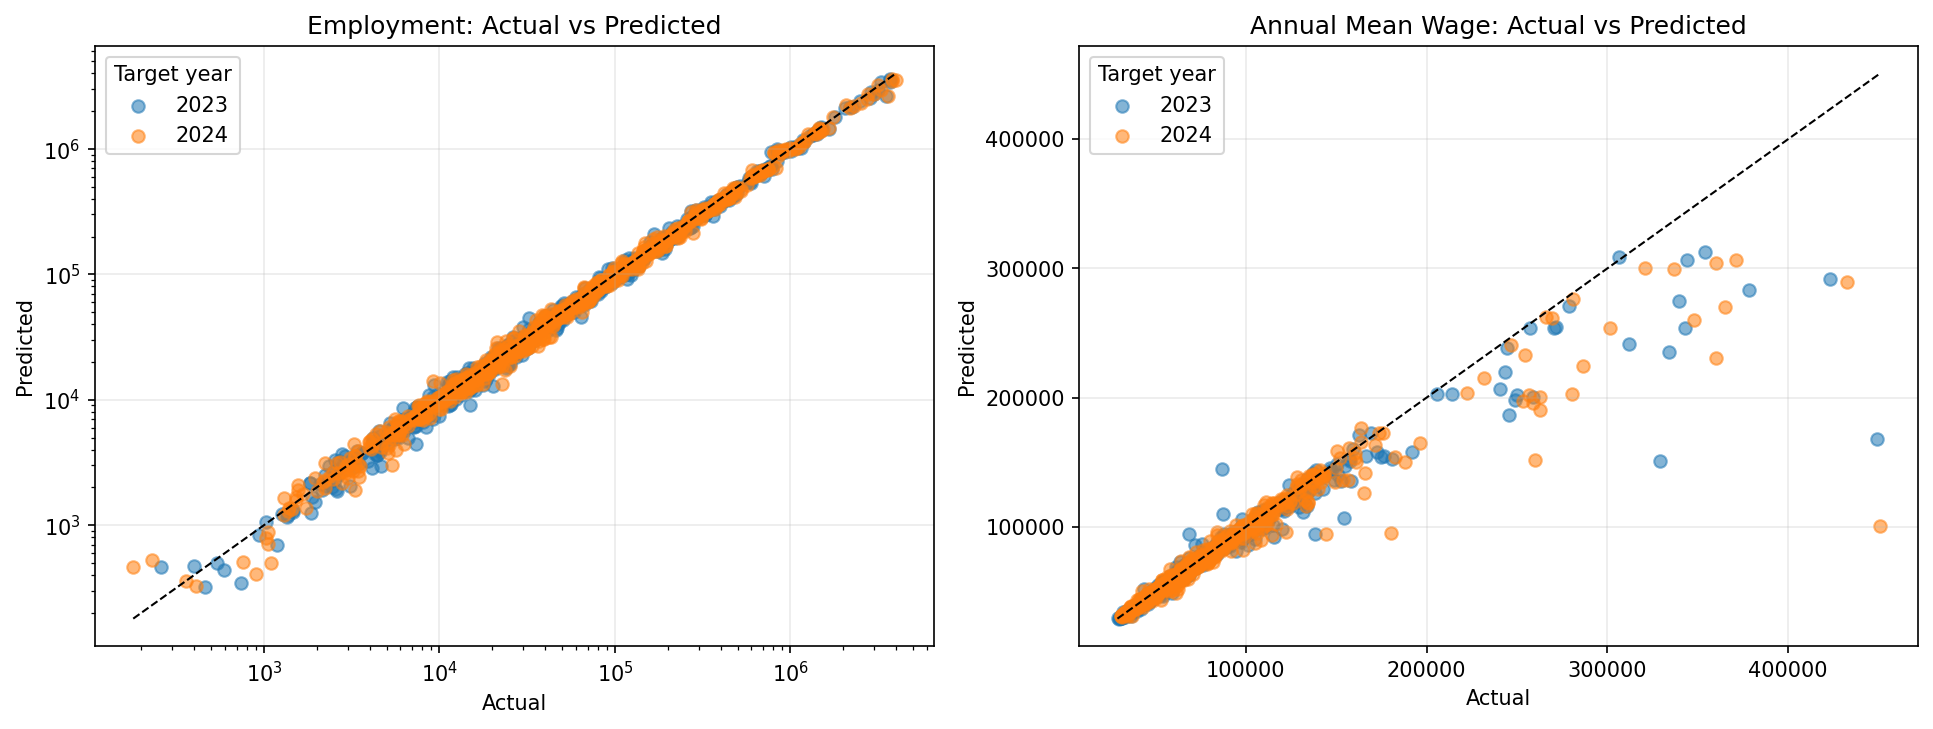

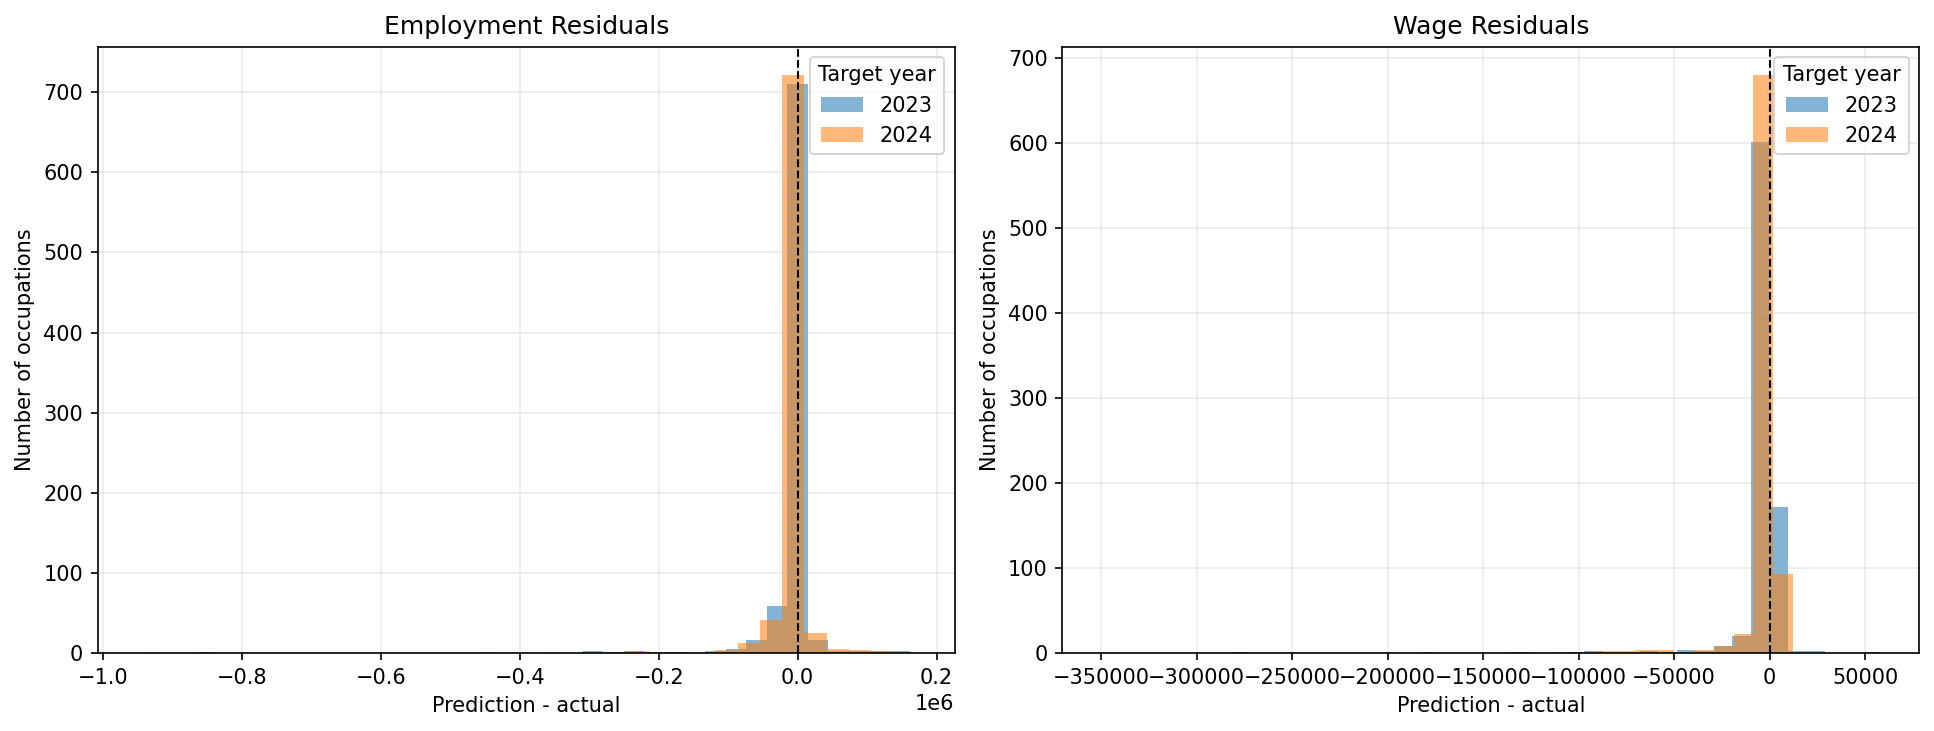

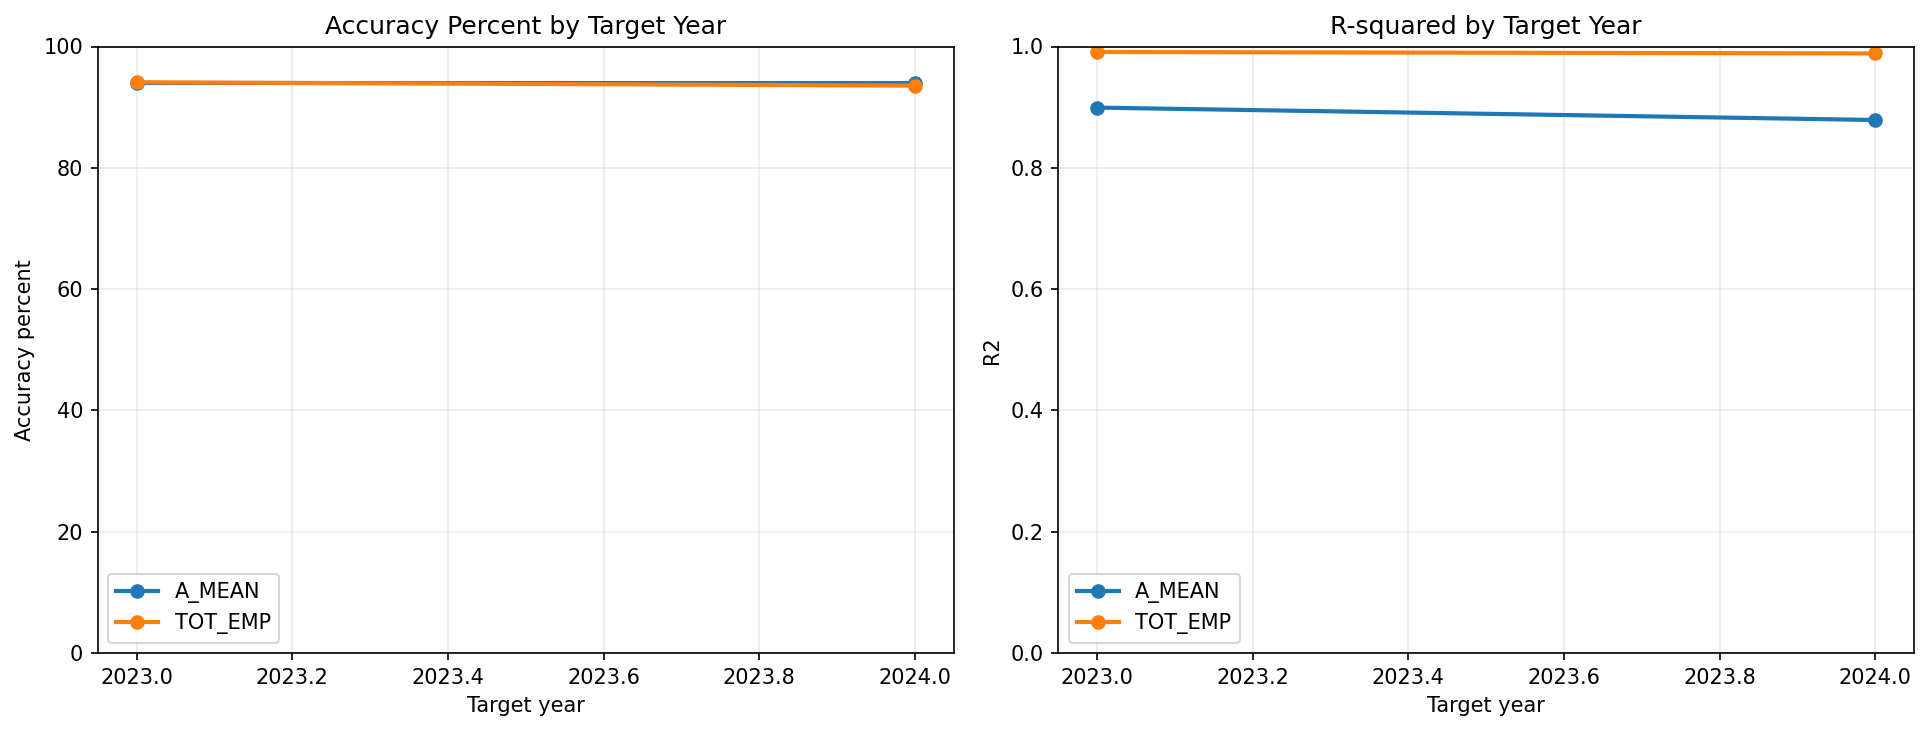

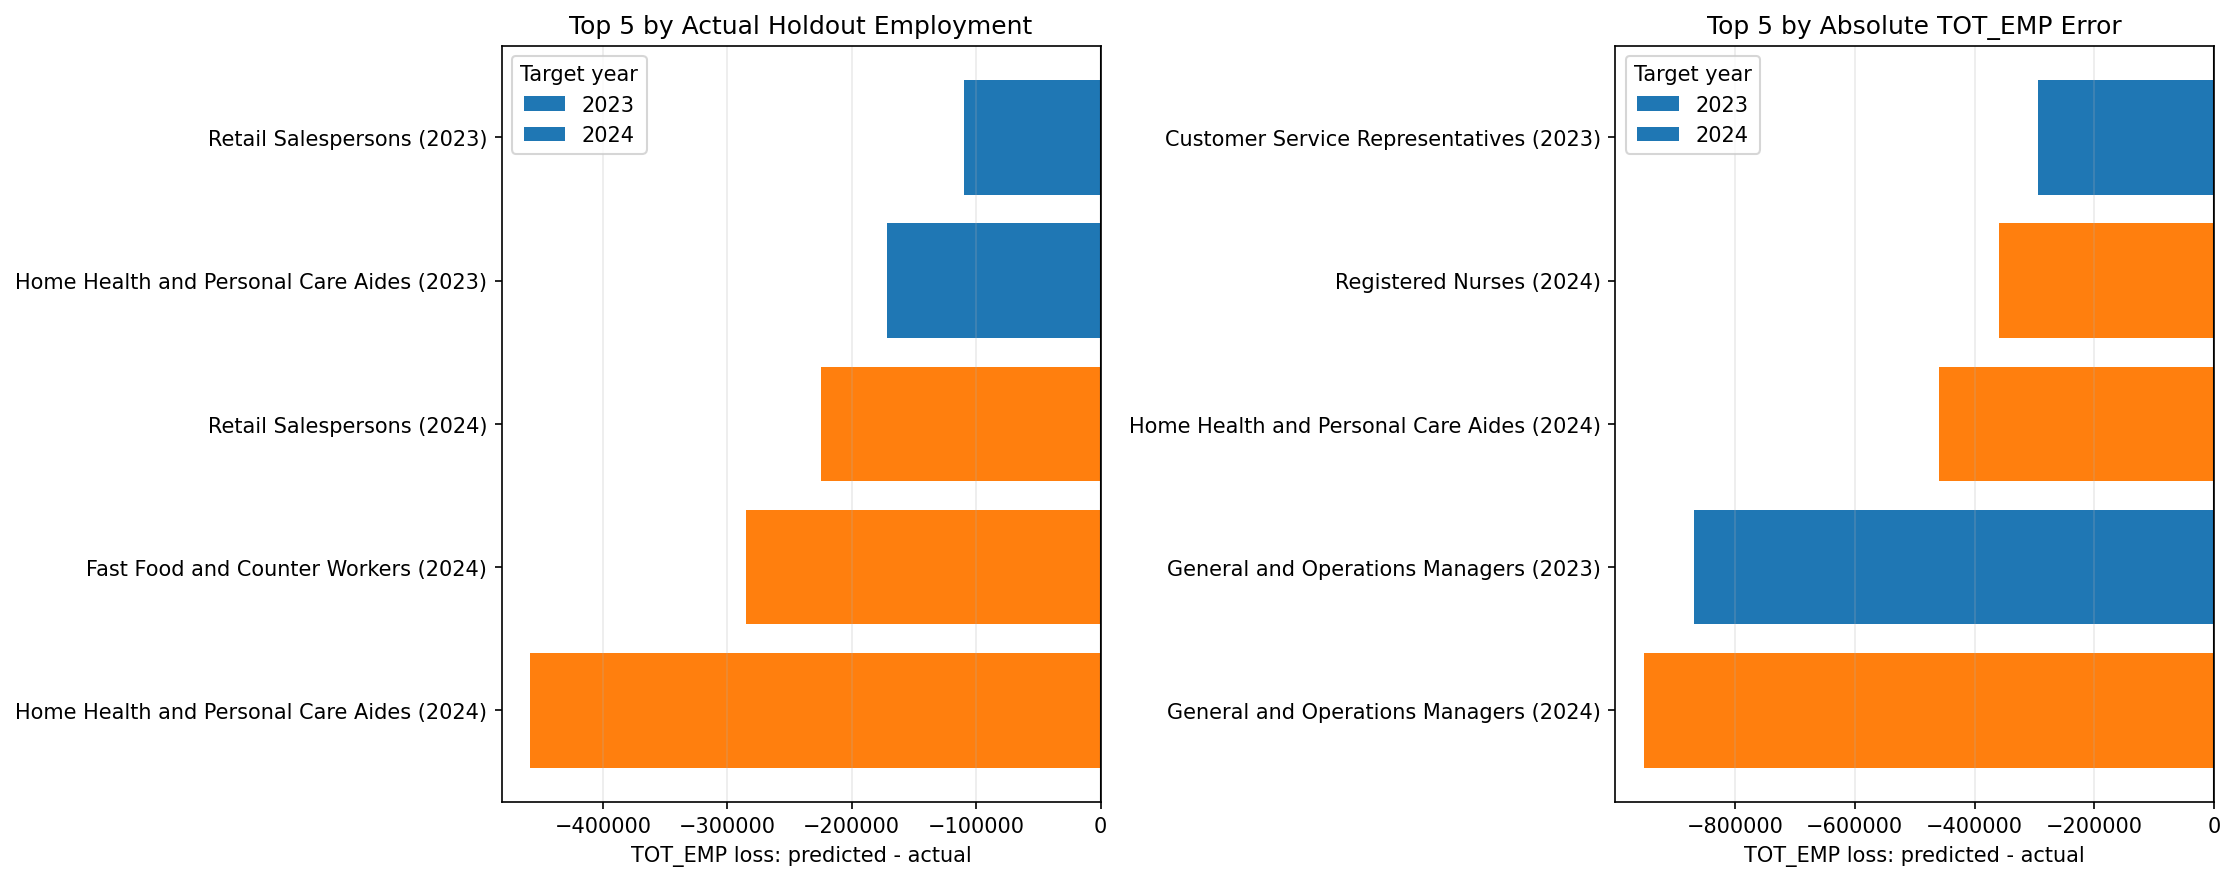

,TARGET_YEAR,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,TOT_EMP_LOSS
742,2024,31-1120,Home Health and Personal Care Aides,3988140,3.529607e+06,-458532.970029
954,2024,41-2031,Retail Salespersons,3800250,3.575772e+06,-224478.460056
844,2024,35-3023,Fast Food and Counter Workers,3780930,3.496046e+06,-284884.121912
741,2023,31-1120,Home Health and Personal Care Aides,3689350,3.517553e+06,-171797.350898
953,2023,41-2031,Retail Salespersons,3684740,3.574715e+06,-110025.413808


,TARGET_YEAR,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,TOT_EMP_LOSS
3,2024,11-1021,General and Operations Managers,3584420,2.632558e+06,-951862.393943
2,2023,11-1021,General and Operations Managers,3507810,2.639292e+06,-868517.741403
742,2024,31-1120,Home Health and Personal Care Aides,3988140,3.529607e+06,-458532.970029
640,2024,29-1141,Registered Nurses,3282010,2.923297e+06,-358713.104199
1017,2023,43-4051,Customer Service Representatives,2858710,2.564559e+06,-294150.942364


In [24]:
from IPython.display import Image, display

PREDICTION_YEAR_COLORS = {
    2023: "tab:blue",
    2024: "tab:orange",
}


def save_and_display(fig, filename: str) -> None:
    path = PROJECT_ROOT / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(path)))


# 1) Actual vs. predicted plots show whether predictions track the true values.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
actual_predicted_specs = [
    ("TOT_EMP", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "Employment", True),
    ("A_MEAN", "ACTUAL_A_MEAN", "PREDICTED_A_MEAN", "Annual Mean Wage", False),
]

for ax, (_, actual_col, predicted_col, title, use_log_scale) in zip(axes, actual_predicted_specs):
    actual = predictions[actual_col]
    predicted = predictions[predicted_col]
    plot_min = min(actual.min(), predicted.min())
    plot_max = max(actual.max(), predicted.max())

    for target_year, year_predictions in predictions.groupby("TARGET_YEAR"):
        ax.scatter(
            year_predictions[actual_col],
            year_predictions[predicted_col],
            alpha=0.55,
            color=PREDICTION_YEAR_COLORS.get(int(target_year), "tab:gray"),
            label=str(target_year),
        )
    ax.plot([plot_min, plot_max], [plot_min, plot_max], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{title}: Actual vs Predicted")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.25)
    ax.legend(title="Target year")
    if use_log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")

fig.tight_layout()
save_and_display(fig, "model_actual_vs_predicted.png")

# 2) Residual distributions show whether errors are centered near zero.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
residual_specs = [
    ("TOT_EMP", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "Employment Residuals"),
    ("A_MEAN", "ACTUAL_A_MEAN", "PREDICTED_A_MEAN", "Wage Residuals"),
]

for ax, (_, actual_col, predicted_col, title) in zip(axes, residual_specs):
    for target_year, year_predictions in predictions.groupby("TARGET_YEAR"):
        residual = year_predictions[predicted_col] - year_predictions[actual_col]
        ax.hist(
            residual,
            bins=35,
            alpha=0.55,
            color=PREDICTION_YEAR_COLORS.get(int(target_year), "tab:gray"),
            label=str(target_year),
        )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Prediction - actual")
    ax.set_ylabel("Number of occupations")
    ax.grid(alpha=0.25)
    ax.legend(title="Target year")

fig.tight_layout()
save_and_display(fig, "model_residual_distributions.png")

# 3) Year-by-year metrics make holdout performance easy to compare.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for target, target_metrics in metrics_by_year.groupby("target"):
    axes[0].plot(
        target_metrics["split"],
        target_metrics["ACCURACY_PERCENT"],
        marker="o",
        linewidth=2,
        label=target,
    )
    axes[1].plot(
        target_metrics["split"],
        target_metrics["R2"],
        marker="o",
        linewidth=2,
        label=target,
    )

axes[0].set_title("Accuracy Percent by Target Year")
axes[0].set_xlabel("Target year")
axes[0].set_ylabel("Accuracy percent")
axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].set_title("R-squared by Target Year")
axes[1].set_xlabel("Target year")
axes[1].set_ylabel("R2")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
save_and_display(fig, "model_metrics_by_year.png")

# 4) TOT_EMP loss is prediction minus actual employment for the requested top-five views.
tot_emp_loss = predictions.assign(
    TOT_EMP_LOSS=predictions["PREDICTED_TOT_EMP"] - predictions["ACTUAL_TOT_EMP"],
    ABS_TOT_EMP_LOSS=lambda data: data["TOT_EMP_LOSS"].abs(),
    OCC_YEAR_LABEL=lambda data: data["OCC_TITLE"] + " (" + data["TARGET_YEAR"].astype(str) + ")",
)

top5_by_actual_emp = tot_emp_loss.nlargest(5, "ACTUAL_TOT_EMP")
top5_by_abs_error = tot_emp_loss.nlargest(5, "ABS_TOT_EMP_LOSS")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top5_specs = [
    (top5_by_actual_emp, "Top 5 by Actual Holdout Employment"),
    (top5_by_abs_error, "Top 5 by Absolute TOT_EMP Error"),
]

for ax, (top5_data, title) in zip(axes, top5_specs):
    plot_data = top5_data.sort_values("TOT_EMP_LOSS")
    colors = [PREDICTION_YEAR_COLORS.get(int(year), "tab:gray") for year in plot_data["TARGET_YEAR"]]
    ax.barh(plot_data["OCC_YEAR_LABEL"], plot_data["TOT_EMP_LOSS"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("TOT_EMP loss: predicted - actual")
    ax.grid(axis="x", alpha=0.25)
    for target_year, color in PREDICTION_YEAR_COLORS.items():
        ax.barh([], [], color=color, label=str(target_year))
    ax.legend(title="Target year")

fig.tight_layout()
save_and_display(fig, "top5_tot_emp_loss.png")

display(
    top5_by_actual_emp[
        ["TARGET_YEAR", "OCC_CODE", "OCC_TITLE", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "TOT_EMP_LOSS"]
    ]
)
display(
    top5_by_abs_error[
        ["TARGET_YEAR", "OCC_CODE", "OCC_TITLE", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "TOT_EMP_LOSS"]
    ]
)

In [25]:
predictions["ABS_EMP_ERROR"] = (predictions["ACTUAL_TOT_EMP"] - predictions["PREDICTED_TOT_EMP"]).abs()
predictions["EMP_PCT_ERROR"] = predictions["ABS_EMP_ERROR"] / predictions["ACTUAL_TOT_EMP"]
predictions["ABS_WAGE_ERROR"] = (predictions["ACTUAL_A_MEAN"] - predictions["PREDICTED_A_MEAN"]).abs()
predictions["WAGE_PCT_ERROR"] = predictions["ABS_WAGE_ERROR"] / predictions["ACTUAL_A_MEAN"]

largest_emp_errors = predictions.sort_values("ABS_EMP_ERROR", ascending=False).head(15)
largest_emp_errors[[
    "OCC_CODE",
    "OCC_TITLE",
    "ACTUAL_TOT_EMP",
    "PREDICTED_TOT_EMP",
    "EMP_PCT_ERROR",
    "ACTUAL_A_MEAN",
    "PREDICTED_A_MEAN",
    "WAGE_PCT_ERROR",
]]

,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,EMP_PCT_ERROR,ACTUAL_A_MEAN,PREDICTED_A_MEAN,WAGE_PCT_ERROR
3,11-1021,General and Operations Managers,3584420,2.632558e+06,0.265555,133120,116283.206604,0.126478
2,11-1021,General and Operations Managers,3507810,2.639292e+06,0.247595,129330,115014.403725,0.110690
742,31-1120,Home Health and Personal Care Aides,3988140,3.529607e+06,0.114974,34990,30728.776539,0.121784
640,29-1141,Registered Nurses,3282010,2.923297e+06,0.109297,98430,82045.814472,0.166455
1017,43-4051,Customer Service Representatives,2858710,2.564559e+06,0.102896,43520,40001.565644,0.080846
844,35-3023,Fast Food and Counter Workers,3780930,3.496046e+06,0.075348,31350,30224.469935,0.035902
843,35-3023,Fast Food and Counter Workers,3676580,3.395372e+06,0.076486,30110,29250.564049,0.028543
1631,53-7062,"Laborers and Freight, Stock, and Material Move...",3008300,2.735524e+06,0.090674,39760,38295.864201,0.036824
1632,53-7062,"Laborers and Freight, Stock, and Material Move...",2982530,2.724331e+06,0.086570,41420,38667.391555,0.066456
639,29-1141,Registered Nurses,3175390,2.928678e+06,0.077695,94480,80934.787475,0.143366


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for target_year, year_predictions in predictions.groupby("TARGET_YEAR"):
    color = PREDICTION_YEAR_COLORS.get(int(target_year), "tab:gray")
    axes[0].scatter(
        year_predictions["ACTUAL_TOT_EMP"],
        year_predictions["PREDICTED_TOT_EMP"],
        alpha=0.55,
        color=color,
        label=str(target_year),
    )
    axes[1].scatter(
        year_predictions["ACTUAL_A_MEAN"],
        year_predictions["PREDICTED_A_MEAN"],
        alpha=0.55,
        color=color,
        label=str(target_year),
    )

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Employment: Actual vs Predicted")
axes[0].set_xlabel("Actual next-year employment")
axes[0].set_ylabel("Predicted next-year employment")
axes[0].legend(title="Target year")

axes[1].set_title("Annual Mean Wage: Actual vs Predicted")
axes[1].set_xlabel("Actual next-year annual mean wage")
axes[1].set_ylabel("Predicted next-year annual mean wage")
axes[1].legend(title="Target year")

plt.tight_layout()

In [27]:
# Train on all known one-year transitions, then forecast one year beyond the latest feature year.
final_model = model
final_model.fit(model_data[available_features], model_data[TARGET_COLUMNS])

latest_year = int(panel["YEAR"].max())
latest_features = panel[panel["YEAR"].eq(latest_year)].copy()
latest_predictions_log = final_model.predict(latest_features[available_features])

next_year_forecast = pd.DataFrame(
    {
        "FORECAST_FROM_YEAR": latest_year,
        "TARGET_YEAR": latest_year + 1,
        "OCC_CODE": latest_features["OCC_CODE"].to_numpy(),
        "OCC_TITLE": latest_features["OCC_TITLE"].to_numpy(),
        "CURRENT_TOT_EMP": latest_features["TOT_EMP"].to_numpy(),
        "FORECAST_TOT_EMP": np.expm1(latest_predictions_log[:, 0]),
        "CURRENT_A_MEAN": latest_features["A_MEAN"].to_numpy(),
        "FORECAST_A_MEAN": np.expm1(latest_predictions_log[:, 1]),
    }
)
next_year_forecast["FORECAST_EMP_CHANGE"] = next_year_forecast["FORECAST_TOT_EMP"] - next_year_forecast["CURRENT_TOT_EMP"]
next_year_forecast["FORECAST_EMP_GROWTH"] = next_year_forecast["FORECAST_EMP_CHANGE"] / next_year_forecast["CURRENT_TOT_EMP"]
next_year_forecast.sort_values("FORECAST_EMP_CHANGE", ascending=False).head(20)

,FORECAST_FROM_YEAR,TARGET_YEAR,OCC_CODE,OCC_TITLE,CURRENT_TOT_EMP,FORECAST_TOT_EMP,CURRENT_A_MEAN,FORECAST_A_MEAN,FORECAST_EMP_CHANGE,FORECAST_EMP_GROWTH
49,2024,2025,13-1111,Management Analysts,893900.0,9.746790e+05,114710.0,73829.921080,80779.017418,0.090367
785,2024,2025,53-3032,Heavy and Tractor-Trailer Truck Drivers,2070480.0,2.134610e+06,58400.0,53968.637927,64130.473773,0.030974
420,2024,2025,35-2021,Food Preparation Workers,888770.0,9.485830e+05,33940.0,48198.034435,59812.986607,0.067299
54,2024,2025,13-1161,Market Research Analysts and Marketing Special...,861140.0,9.067467e+05,86480.0,74219.880595,45606.715418,0.052961
44,2024,2025,13-1071,Human Resources Specialists,917460.0,9.588298e+05,79730.0,69751.615539,41369.833497,0.045092
262,2024,2025,25-9045,"Teaching Assistants, Except Postsecondary",1375300.0,1.409057e+06,35960.0,47312.437914,33757.120021,0.024545
406,2024,2025,33-9032,Security Guards,1241770.0,1.275017e+06,42890.0,49100.065726,33247.175260,0.026774
372,2024,2025,31-1131,Nursing Assistants,1388430.0,1.415043e+06,41270.0,48325.801984,26612.868365,0.019168
61,2024,2025,13-2052,Personal Financial Advisors,270480.0,2.956643e+05,160210.0,172431.357987,25184.276776,0.093110
432,2024,2025,37-2012,Maids and Housekeeping Cleaners,854910.0,8.789207e+05,36180.0,47809.356843,24010.656434,0.028086


## Interpretation and Next Steps

The model predicts each detailed occupation's next-year employment and annual mean wage. It is a regression model, so the accuracy score is based on prediction error rather than classification correctness. The headline `ACCURACY_PERCENT` is `1 - WAPE`, meaning it measures how close the model's total absolute prediction error is to the total actual value on the 2023-2024 holdout set.

The holdout results should be treated as a backtest of one-year-ahead predictions. The final forecast cell then retrains on all known one-year transitions through 2024 and projects one year beyond the latest feature year reconstructed from the model-ready CSV.

Recommended final project workflow:

1. Compare Random Forest against simple baselines such as last-year carry-forward and linear trend.
2. Add prediction intervals or scenario ranges before presenting forecasts as decisions.
3. Report uncertainty clearly, especially for occupations affected by SOC classification changes or BLS suppression symbols.
4. Only try RNN/LSTM if you add much more frequent data, such as monthly job postings or quarterly labor-market indicators. Annual BLS files alone are too short for a reliable deep learning sequence model.